# Customer Segmentation Analysis

This project uses customer purchasing behaviour to divide customers into meaningful groups using RFM analysis and K-Means clustering.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 1. Load and Inspect the Dataset

First, we load the Online Retail dataset and inspect its structure, columns, data types, missing values, and duplicate records.

In [3]:
df = pd.read_csv("online_retail.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


## 2. Data Cleaning

We remove transactions without a CustomerID because they cannot be assigned to a customer. Duplicate rows are also removed, and InvoiceDate is converted to datetime format.

In [4]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Data Types:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 5268


In [5]:
# Remove rows without CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove duplicate rows
df = df.drop_duplicates()

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]) 

print("Shape after cleaning:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape after cleaning: (401604, 8)

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


## 3. Calculate Total Amount

Total Amount represents the money generated by each transaction.

Total Amount = Quantity × Unit Price

In [6]:
df["Total Amount"] = df["Quantity"] * df["UnitPrice"]

print(df[["Quantity", "UnitPrice", "Total Amount"]].head())

   Quantity  UnitPrice  Total Amount
0         6       2.55         15.30
1         6       3.39         20.34
2         8       2.75         22.00
3         6       3.39         20.34
4         6       3.39         20.34


## 4. RFM Analysis

RFM stands for Recency, Frequency, and Monetary.

- Recency: How recently a customer purchased.
- Frequency: How many transactions a customer made.
- Monetary: How much money a customer spent.

In [7]:
# Set the latest date in the dataset
latest_date = df["InvoiceDate"].max()

# Calculate RFM for each customer
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (latest_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Total Amount": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         325          2      0.00
12347.0           1          7   4310.00
12348.0          74          4   1797.24
12349.0          18          1   1757.55
12350.0         309          1    334.40


In [8]:
print(rfm.describe())

           Recency    Frequency       Monetary
count  4372.000000  4372.000000    4372.000000
mean     91.047118     5.075480    1893.531433
std     100.765435     9.338754    8218.696204
min       0.000000     1.000000   -4287.630000
25%      16.000000     1.000000     291.795000
50%      49.000000     3.000000     644.070000
75%     142.000000     5.000000    1608.335000
max     373.000000   248.000000  279489.020000


In [9]:
# Remove cancelled transactions
df = df[~df["InvoiceNo"].str.startswith("C")]

# Keep only positive quantity and price
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Recalculate Total Amount
df["Total Amount"] = df["Quantity"] * df["UnitPrice"]

# Recalculate RFM
latest_date = df["InvoiceDate"].max()

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (latest_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Total Amount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"] 

print(rfm.describe())  

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     91.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       0.000000     1.000000       3.750000
25%      17.000000     1.000000     306.482500
50%      50.000000     2.000000     668.570000
75%     141.000000     5.000000    1660.597500
max     373.000000   209.000000  280206.020000


## 5. Feature Scaling

The RFM features have different numerical ranges. StandardScaler puts them on a comparable scale so that one feature does not dominate the clustering process.

In [10]:
# Standardize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Convert back to DataFrame
rfm_scaled = pd.DataFrame(  
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)   

print(rfm_scaled.head())      

             Recency  Frequency  Monetary
CustomerID                               
12346.0     2.334574  -0.425097  8.363010
12347.0    -0.905340   0.354417  0.251699
12348.0    -0.175360  -0.035340 -0.027988
12349.0    -0.735345  -0.425097 -0.032406
12350.0     2.174578  -0.425097 -0.190812


## 6. Elbow Method

The Elbow Method helps us choose a suitable number of clusters for K-Means by comparing different values of K.

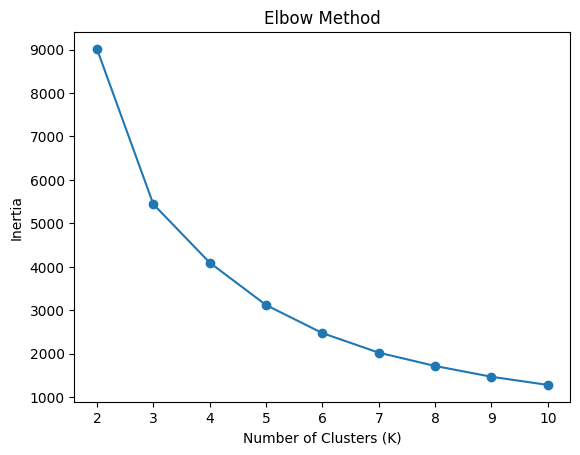

In [11]:
# Elbow Method
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## 7. K-Means Clustering

K-Means groups customers with similar purchasing behaviour into clusters based on their RFM values.

In [12]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())
print("\nNumber of customers in each cluster:")
print(rfm["Cluster"].value_counts().sort_index())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         325          1  77183.60        3
12347.0           1          7   4310.00        0
12348.0          74          4   1797.24        0
12349.0          18          1   1757.55        0
12350.0         309          1    334.40        1

Number of customers in each cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


## 8. Cluster Profiling

We calculate the average Recency, Frequency, and Monetary values for each cluster to understand the characteristics of each customer group.

In [13]:
# Calculate average RFM values for each cluster
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         42.702685   3.682711    1353.625312
1        247.075914   1.552015     478.848773
2          6.384615  82.538462  127187.959231
3         14.500000  22.333333   12690.500392


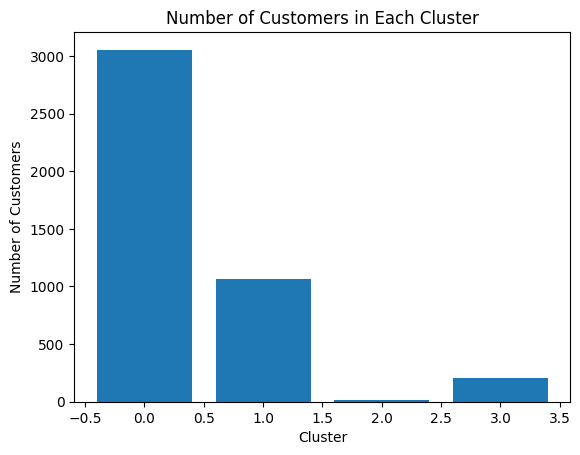

In [14]:
# Count customers in each cluster
cluster_counts = rfm["Cluster"].value_counts().sort_index()

# Create bar chart
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")
plt.show()

In [15]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()


In [16]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         42.702685   3.682711    1353.625312
1        247.075914   1.552015     478.848773
2          6.384615  82.538462  127187.959231
3         14.500000  22.333333   12690.500392


In [17]:
# Give meaningful names to the customer clusters
cluster_names = {
    0: "Regular Customers",
    1: "Inactive Customers",
    2: "VIP Customers",
    3: "Loyal High-Value Customers"
}

rfm["Customer Segment"] = rfm["Cluster"].map(cluster_names)

print(rfm[["Recency", "Frequency", "Monetary", "Customer Segment"]].head())

            Recency  Frequency  Monetary            Customer Segment
CustomerID                                                          
12346.0         325          1  77183.60  Loyal High-Value Customers
12347.0           1          7   4310.00           Regular Customers
12348.0          74          4   1797.24           Regular Customers
12349.0          18          1   1757.55           Regular Customers
12350.0         309          1    334.40          Inactive Customers


## 9. Customer Segment Visualization

Scatter plots are used to visualize relationships between RFM features and identify differences between customer segments.

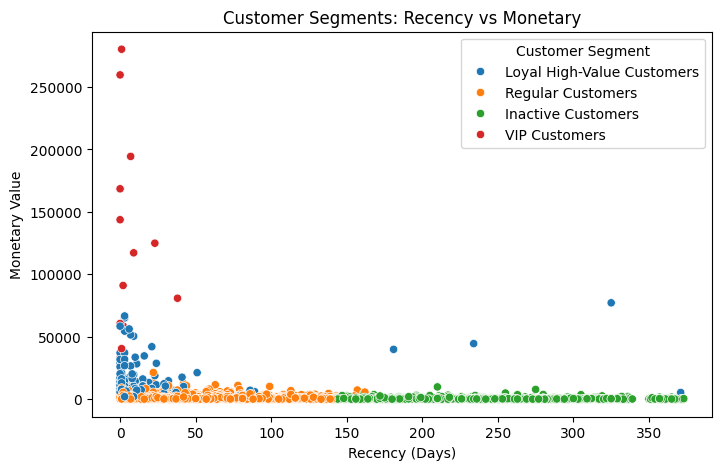

In [18]:
# Visualize customer segments
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Customer Segment"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.show()

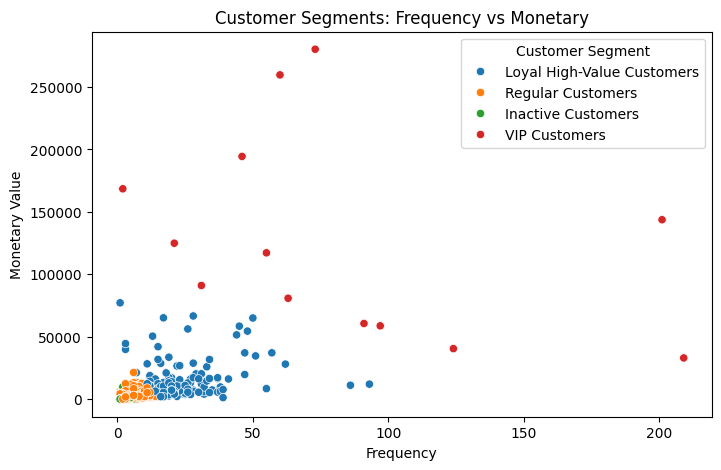

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Customer Segment"
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.show()

In [20]:
# Count customers in each segment
segment_counts = rfm["Customer Segment"].value_counts()

print(segment_counts)

Customer Segment
Regular Customers             3054
Inactive Customers            1067
Loyal High-Value Customers     204
VIP Customers                   13
Name: count, dtype: int64


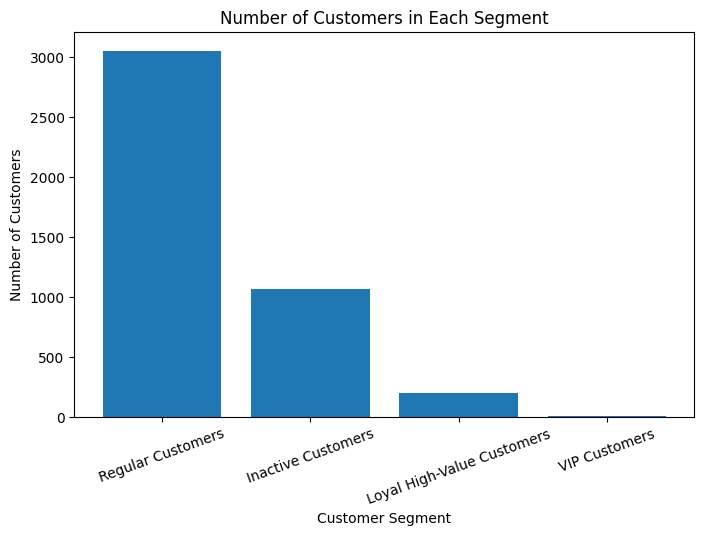

In [21]:
# Customer count by segment

segment_counts = rfm["Customer Segment"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(segment_counts.index, segment_counts.values)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Segment")
plt.xticks(rotation=20)
plt.show()

## Marketing Recommendations

### 1. Regular Customers
This is the largest customer segment with 3,054 customers. They show moderate purchasing activity and spending.
**Recommendation:** Offer personalized discounts, product recommendations, and loyalty rewards to encourage them to purchase more frequently.

### 2. Inactive Customers
There are 1,067 inactive customers who have not purchased for a long time.
**Recommendation:** Use re-engagement campaigns such as special discounts, reminder emails, and limited-time offers to encourage them to return.

### 3. Loyal High-Value Customers
There are 204 customers who purchase frequently and spend significantly more.
**Recommendation:** Provide loyalty benefits, early access to new products, exclusive offers, and personalized services to retain them.

### 4. VIP Customers
There are only 13 VIP customers, but they have extremely high purchasing frequency and spending.
**Recommendation:** Give these customers premium treatment, exclusive rewards, personalized communication, and dedicated customer support to retain their business.

## Conclusion

The customer segmentation analysis divided 4,338 customers into four groups using RFM analysis and K-Means clustering.

The largest segment was Regular Customers with 3,054 customers, followed by Inactive Customers with 1,067 customers. There were 204 Loyal High-Value Customers and 13 VIP Customers.

The analysis shows that customers have different purchasing behaviours and therefore should not all receive the same marketing strategy.

Key recommendations:
- Encourage Regular Customers to purchase more frequently through personalized offers and loyalty rewards.
- Re-engage Inactive Customers using special discounts and targeted campaigns.
- Retain Loyal High-Value Customers through exclusive benefits and personalized services.
- Give VIP Customers premium treatment and dedicated support to maintain their loyalty.
